<a href="https://colab.research.google.com/github/Uriel-CS/Regresion-Logistica-para-Predecir-Enfermedades-Cardiacas/blob/main/Heart_Disease_Prediction_Using_Decision_Tree.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
disease_df = pd.read_csv("/content/framingham.csv")

disease_df.rename(columns ={'male':'Sex_male'}, inplace = True)
disease_df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4240 entries, 0 to 4239
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Sex_male         4240 non-null   int64  
 1   age              4240 non-null   int64  
 2   education        4135 non-null   float64
 3   currentSmoker    4240 non-null   int64  
 4   cigsPerDay       4211 non-null   float64
 5   BPMeds           4187 non-null   float64
 6   prevalentStroke  4240 non-null   int64  
 7   prevalentHyp     4240 non-null   int64  
 8   diabetes         4240 non-null   int64  
 9   totChol          4190 non-null   float64
 10  sysBP            4240 non-null   float64
 11  diaBP            4240 non-null   float64
 12  BMI              4221 non-null   float64
 13  heartRate        4239 non-null   float64
 14  glucose          3852 non-null   float64
 15  TenYearCHD       4240 non-null   int64  
dtypes: float64(9), int64(7)
memory usage: 530.1 KB


In [ ]:
# removing NaN / NULL values
disease_df.dropna(axis = 0, inplace = True)
print(disease_df.head(), disease_df.shape)
print(disease_df.TenYearCHD.value_counts())

   Sex_male  age  education  currentSmoker  cigsPerDay  BPMeds  \
0         1   39        4.0              0         0.0     0.0   
1         0   46        2.0              0         0.0     0.0   
2         1   48        1.0              1        20.0     0.0   
3         0   61        3.0              1        30.0     0.0   
4         0   46        3.0              1        23.0     0.0   

   prevalentStroke  prevalentHyp  diabetes  totChol  sysBP  diaBP    BMI  \
0                0             0         0    195.0  106.0   70.0  26.97   
1                0             0         0    250.0  121.0   81.0  28.73   
2                0             0         0    245.0  127.5   80.0  25.34   
3                0             1         0    225.0  150.0   95.0  28.58   
4                0             0         0    285.0  130.0   84.0  23.10   

   heartRate  glucose  TenYearCHD  
0       80.0     77.0           0  
1       95.0     76.0           0  
2       75.0     70.0           0  
3 

Text(0.5, 1.0, 'Age distribution')

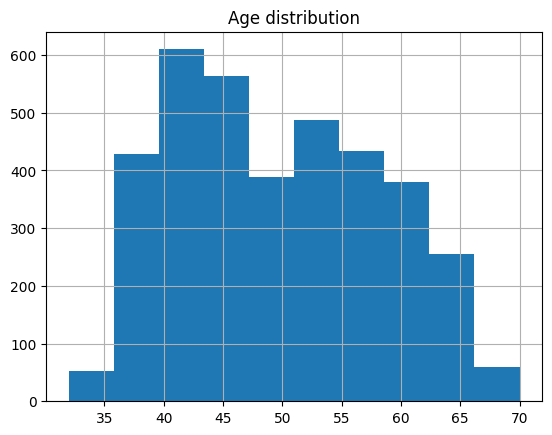

In [ ]:
disease_df["age"].hist()
plt.title("Age distribution")

<ipython-input-10-2bae2d67eee4>:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(disease_df["age"])


<Axes: xlabel='age', ylabel='Density'>

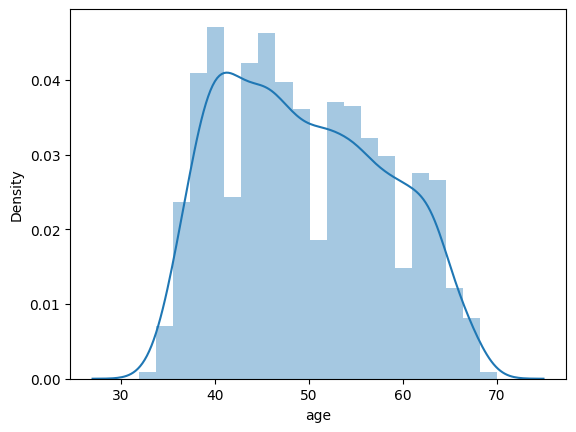

In [ ]:

sns.distplot(disease_df["age"])

In [ ]:

col = list(disease_df.columns)

<ipython-input-6-2823dc8cf0a9>:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(disease_df[disease_df["Sex_male"] == 1]["age"], label = "Male")
<ipython-input-6-2823dc8cf0a9>:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(disease_df[disease_df["Sex_male"] == 0]["age"], label = "Female")


Text(0.5, 1.0, 'Density plot of age by sex')

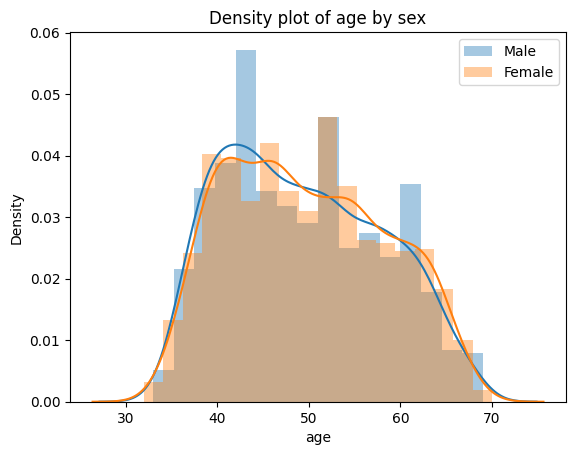

In [ ]:
sns.distplot(disease_df[disease_df["Sex_male"] == 1]["age"], label = "Male")
sns.distplot(disease_df[disease_df["Sex_male"] == 0]["age"], label = "Female")
plt.legend()
plt.title("Density plot of age by sex")

In [ ]:
X = disease_df.drop('TenYearCHD', axis=1)
y = disease_df['TenYearCHD']
x_train,x_test,y_train,y_test = train_test_split(X,y, random_state = 0 , train_size = 0.70)


In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn import tree

In [ ]:
clf = tree.DecisionTreeClassifier()
clf.fit(x_train, y_train)

DecisionTreeClassifier()

In [ ]:
pred = clf.predict(x_test)

In [ ]:
pred

array([0, 0, 0, ..., 0, 0, 0])

In [ ]:
y_test

,TenYearCHD
3079,1
3002,0
1707,0
3855,0
2990,1
...,...
2876,0
892,0
1134,0
2935,0


In [ ]:
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report

In [ ]:
accuracy_score(pred,y_test)

0.7495446265938069

In [ ]:
c_parameter_name = "max_depth"

c_parameter_values = [1,2,3,4,5,6,7,8,9,10,11,12,13,14,15]

df1 = pd.DataFrame(columns = ["max_depth", "accuracy"])
df1


,max_depth,accuracy


In [ ]:
print(classification_report(pred, y_test))
#print(classification_report(y_pred,y_test))

              precision    recall  f1-score   support

           0       0.85      0.85      0.85       909
           1       0.26      0.25      0.26       189

    accuracy                           0.75      1098
   macro avg       0.55      0.55      0.55      1098
weighted avg       0.75      0.75      0.75      1098



In [ ]:
model = tree.DecisionTreeClassifier(max_depth = 5)
model.fit(x_train, y_train)
y_pred = model.predict(x_test)
acc_score = accuracy_score(y_test,y_pred) *100
acc_score

82.33151183970855

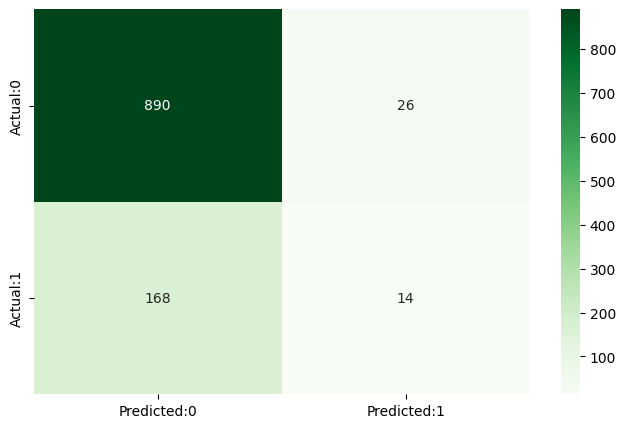

The details for confusion matrix is =
              precision    recall  f1-score   support

           0       0.84      0.97      0.90       916
           1       0.35      0.08      0.13       182

    accuracy                           0.82      1098
   macro avg       0.60      0.52      0.51      1098
weighted avg       0.76      0.82      0.77      1098



In [ ]:
from sklearn.metrics import confusion_matrix, classification_report

cm = confusion_matrix(y_test, y_pred)
conf_matrix = pd.DataFrame(data = cm,
                           columns = ['Predicted:0', 'Predicted:1'],
                           index =['Actual:0', 'Actual:1'])

plt.figure(figsize = (8, 5))
sns.heatmap(conf_matrix, annot = True, fmt = 'd', cmap = "Greens")

plt.show()
print('The details for confusion matrix is =')
print (classification_report(y_test, y_pred))

[Text(0.44932432432432434, 0.9166666666666666, 'x[1] <= 48.5\ngini = 0.25\nsamples = 2560\nvalue = [2185, 375]'),
 Text(0.22297297297297297, 0.75, 'x[11] <= 118.5\ngini = 0.146\nsamples = 1275\nvalue = [1174.0, 101.0]'),
 Text(0.3361486486486487, 0.8333333333333333, 'True  '),
 Text(0.14864864864864866, 0.5833333333333334, 'x[4] <= 14.5\ngini = 0.141\nsamples = 1267\nvalue = [1170, 97]'),
 Text(0.08108108108108109, 0.4166666666666667, 'x[10] <= 190.0\ngini = 0.092\nsamples = 726\nvalue = [691, 35]'),
 Text(0.05405405405405406, 0.25, 'x[12] <= 39.085\ngini = 0.089\nsamples = 725\nvalue = [691, 34]'),
 Text(0.02702702702702703, 0.08333333333333333, 'gini = 0.085\nsamples = 719\nvalue = [687, 32]'),
 Text(0.08108108108108109, 0.08333333333333333, 'gini = 0.444\nsamples = 6\nvalue = [4, 2]'),
 Text(0.10810810810810811, 0.25, 'gini = 0.0\nsamples = 1\nvalue = [0, 1]'),
 Text(0.21621621621621623, 0.4166666666666667, 'x[14] <= 55.5\ngini = 0.203\nsamples = 541\nvalue = [479.0, 62.0]'),
 Text(

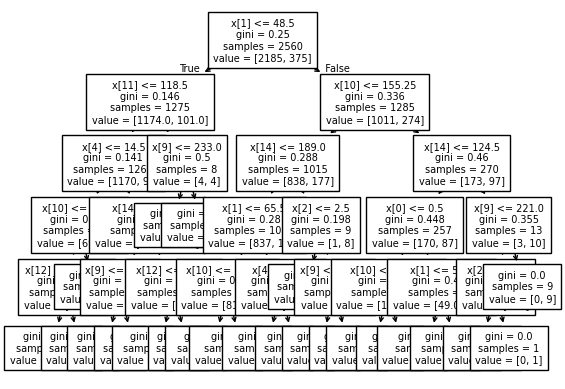

In [ ]:
tree.plot_tree(model, fontsize = 7)

# Tarea

Buscar mejores atributos para el arbol de decisión

In [ ]:
y = disease_df['TenYearCHD']

X = disease_df.drop('age', axis = 1) # axis =1 es
X = X.drop(['prevalentHyp', 'education', 'diabetes', 'sysBP'], axis = 1) #estos son los atributos que yo usé pero ustedes deben buscar unos que funcioenen mejor

X = X.replace(['male', 'female'], [2, 3])
# Hot-encoding the categorical variables

X.fillna(method ='ffill', inplace = True)
# Handling the missing values

<ipython-input-49-b6c0fff0e054>:9: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  X.fillna(method ='ffill', inplace = True)


In [ ]:
criteria = ['gini', 'entropy']
scores = {}

for c in criteria:
	dt = DecisionTreeClassifier(criterion = c)
	dt.fit(x_train, y_train)
	test_score = dt.score(x_test, y_test)
	scores = test_score

print(scores)


0.7586520947176685


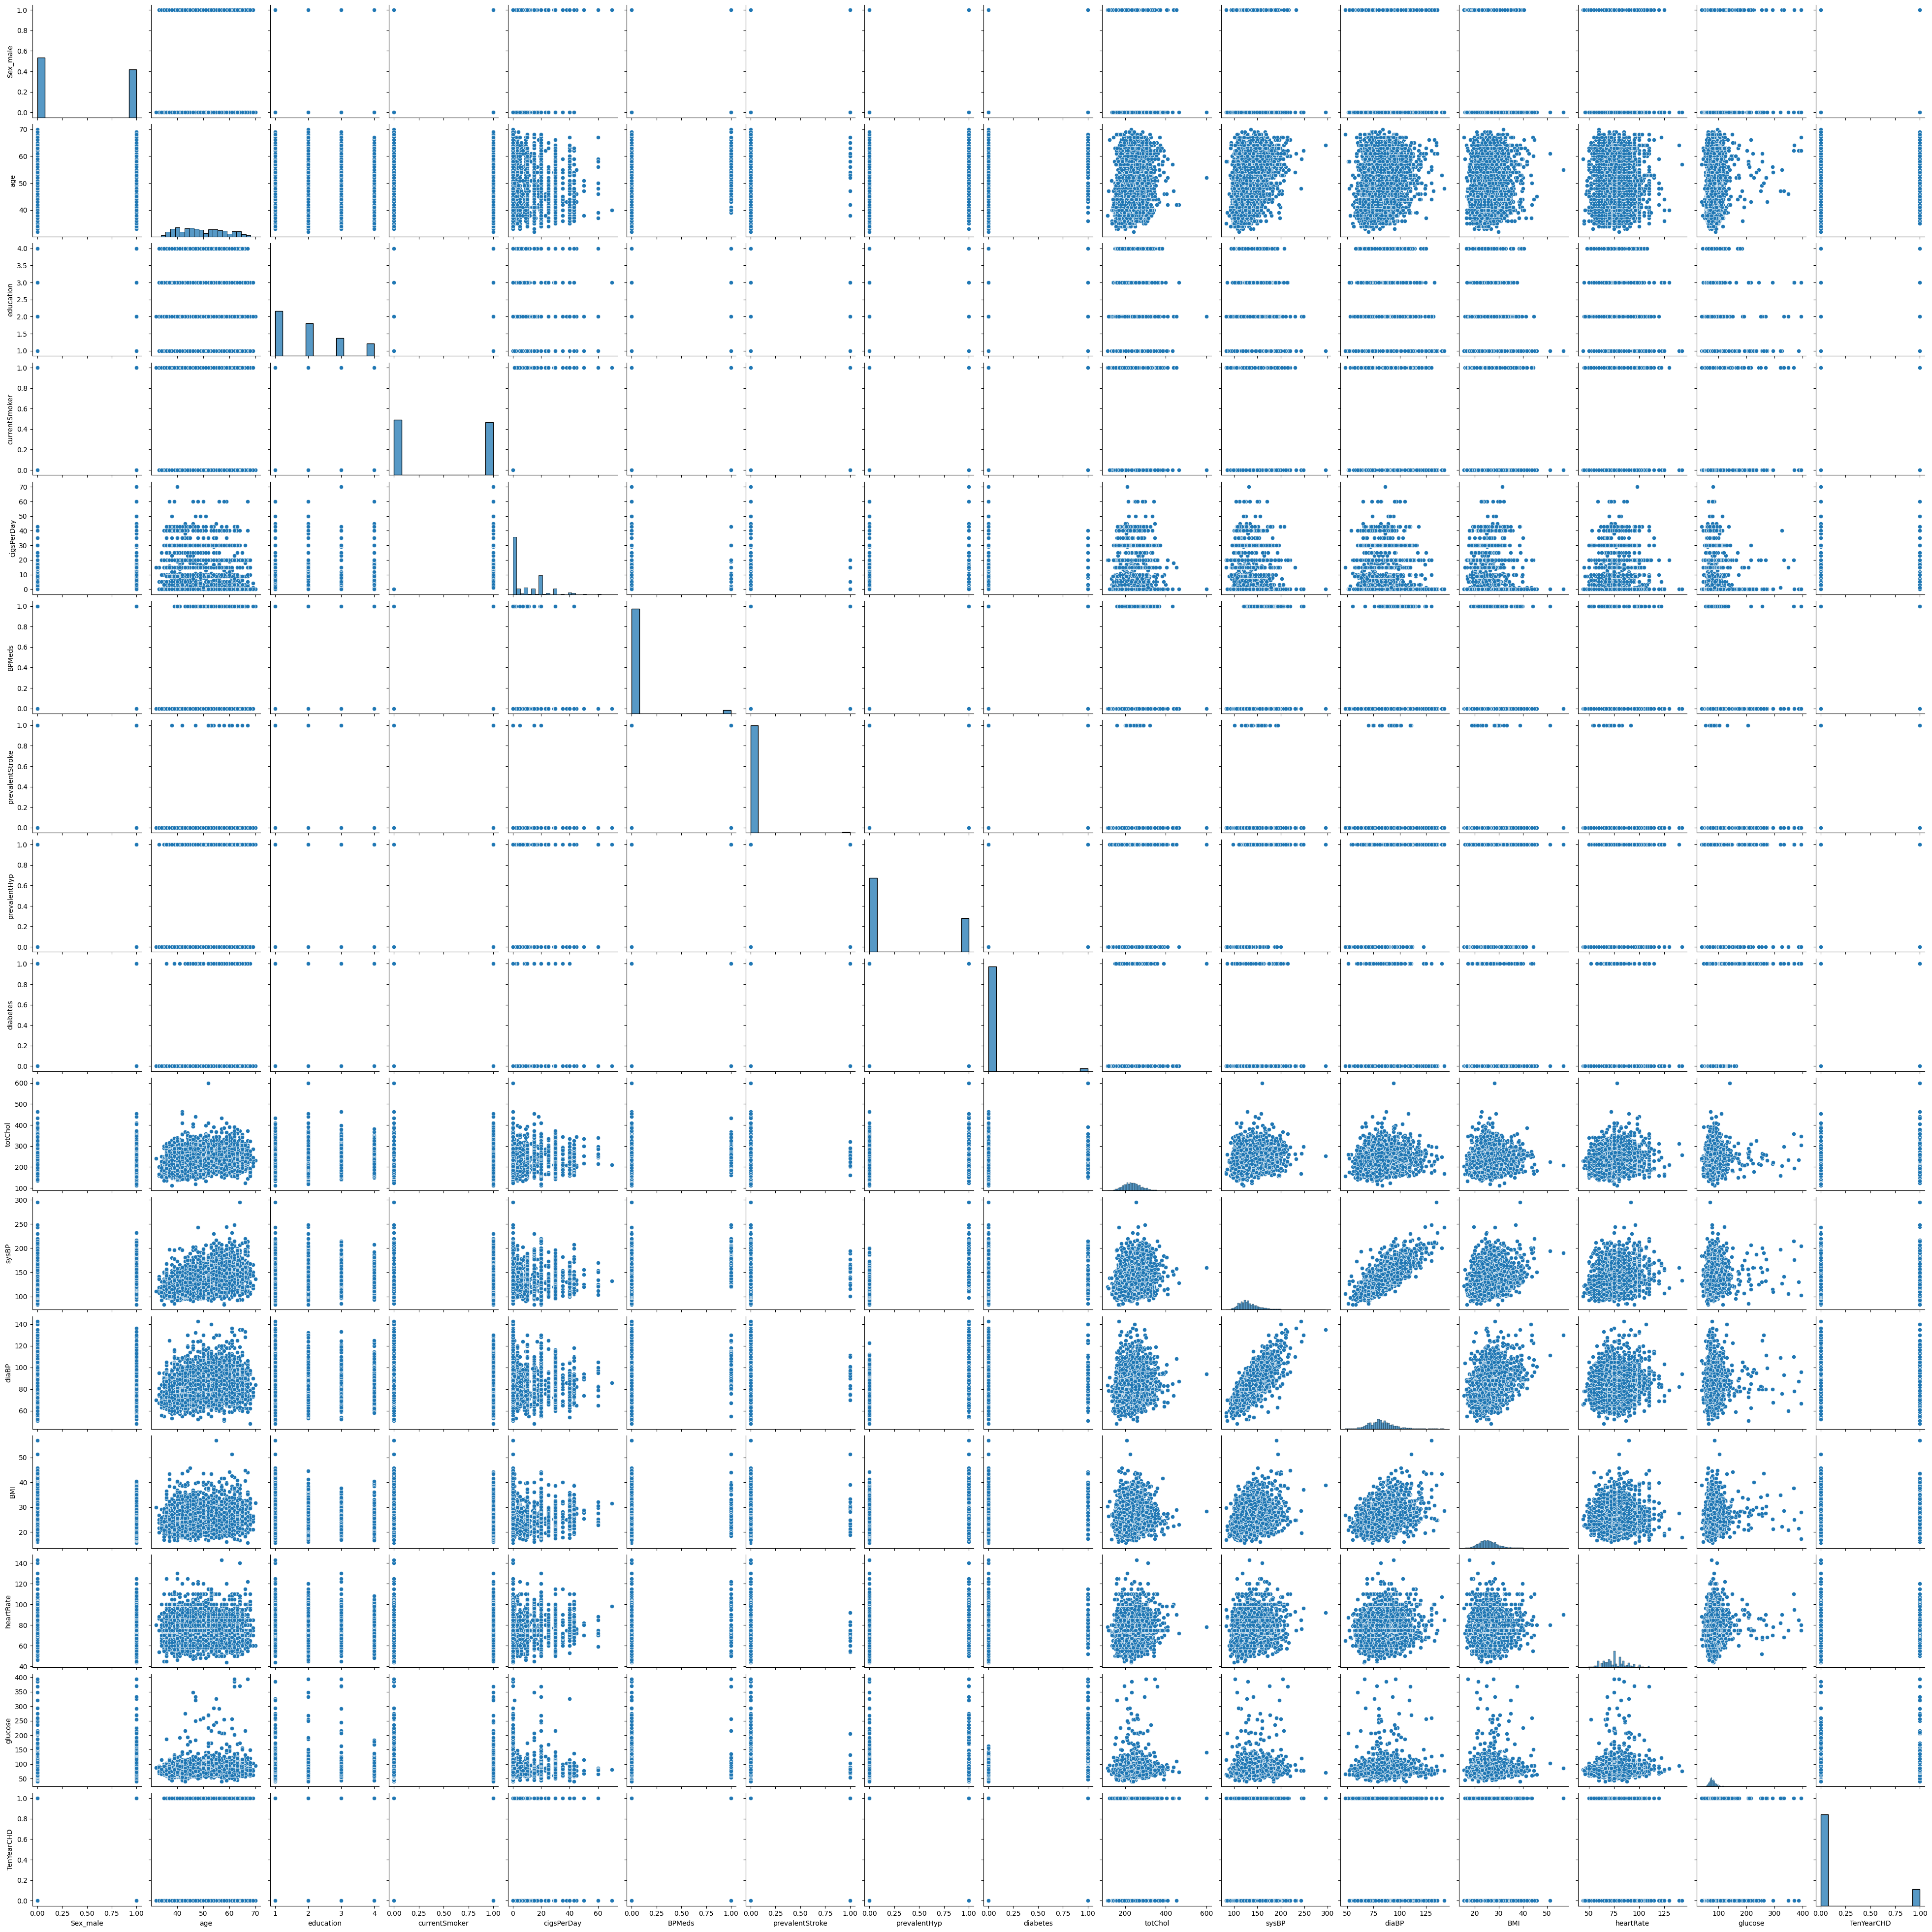

In [ ]:
sns.pairplot(data=disease_df)